# QEA Claims Top 10 Comparison

Builds the Top 10 claims table from raw claims for the selected `CLAIM_YEAR`, then uses `HPCapacity_QEA.xlsx` and `Model Runs ES` to compare claim metrics against QEA modeled capacity, annual therms, and therm/kBtuh.

Wrote claims_by_building_cz_measapp_tsb_top10.xlsx
Wrote outputs\claims_by_building_cz_measapp_tsb_top10_2024.xlsx
Wrote outputs\claims_by_building_cz_measapp_tsb_top10_2024.csv
Wrote outputs\claims_top10_qea_model_comparison.csv
Wrote outputs\claims_top10_qea_model_comparison.xlsx


,claim_building_type,claim_cz,claim_measure_application_type,claim_rows,claim_tsb_share,claim_median_data_request_capacity_kbtuh,qea_modeled_capacity_kbtuh,qea_modeled_capacity_pct_diff_vs_claim_median_data_request (%),claim_median_total_annual_therms,qea_modeled_annual_total_therms,qea_modeled_annual_therms_pct_diff_vs_claim_median (%),claim_median_therm_per_kbtuh,qea_modeled_therm_per_kbtuh,qea_modeled_therm_per_kbtuh_pct_diff_vs_claim_median (%),qea_model_baseline_source,qea_model_run_count
0,Hotel,15,NR,183.000,0.123,161.686,213.806,32.2%,"6,321.923","6,163.280",-2.5%,39.100,28.827,-26.3%,Standard,4.000
1,Hotel,6,NR,144.000,0.121,161.686,156.271,-3.3%,"7,647.748","9,019.637",17.9%,47.300,57.718,22.0%,Standard,4.000
2,Hotel,14,NR,98.000,0.121,161.686,251.491,55.5%,"7,663.916","6,470.361",-15.6%,47.400,25.728,-45.7%,Standard,4.000
3,Hotel,10,NR,100.000,0.093,161.686,197.203,22.0%,"7,469.893","8,692.632",16.4%,46.200,44.080,-4.6%,Standard,4.000
4,Grocery,8,NR,118.000,0.067,161.686,87.269,-46.0%,"5,222.458","3,232.693",-38.1%,32.300,37.043,14.7%,Standard,4.000
5,Hotel,8,NR,62.000,0.063,161.686,167.156,3.4%,"7,437.556","8,734.564",17.4%,46.000,52.254,13.6%,Standard,4.000
6,Hotel,9,NR,77.000,0.059,161.686,210.337,30.1%,"7,486.062","8,805.011",17.6%,46.300,41.861,-9.6%,Standard,4.000
7,Grocery,9,NR,54.000,0.031,161.686,109.676,-32.2%,"5,270.964","3,260.083",-38.2%,32.600,29.725,-8.8%,Standard,4.000
8,Hotel,16,NR,22.000,0.030,161.686,274.614,69.8%,"8,844.224","6,079.696",-31.3%,54.700,22.139,-59.5%,Standard,4.000
9,Hotel,7,NR,8.000,0.027,646.744,159.106,-75.4%,"30,461.642","8,924.117",-70.7%,47.100,56.089,19.1%,Standard,4.000


Wrote outputs\qea_claims_top10_visual_comparison.png


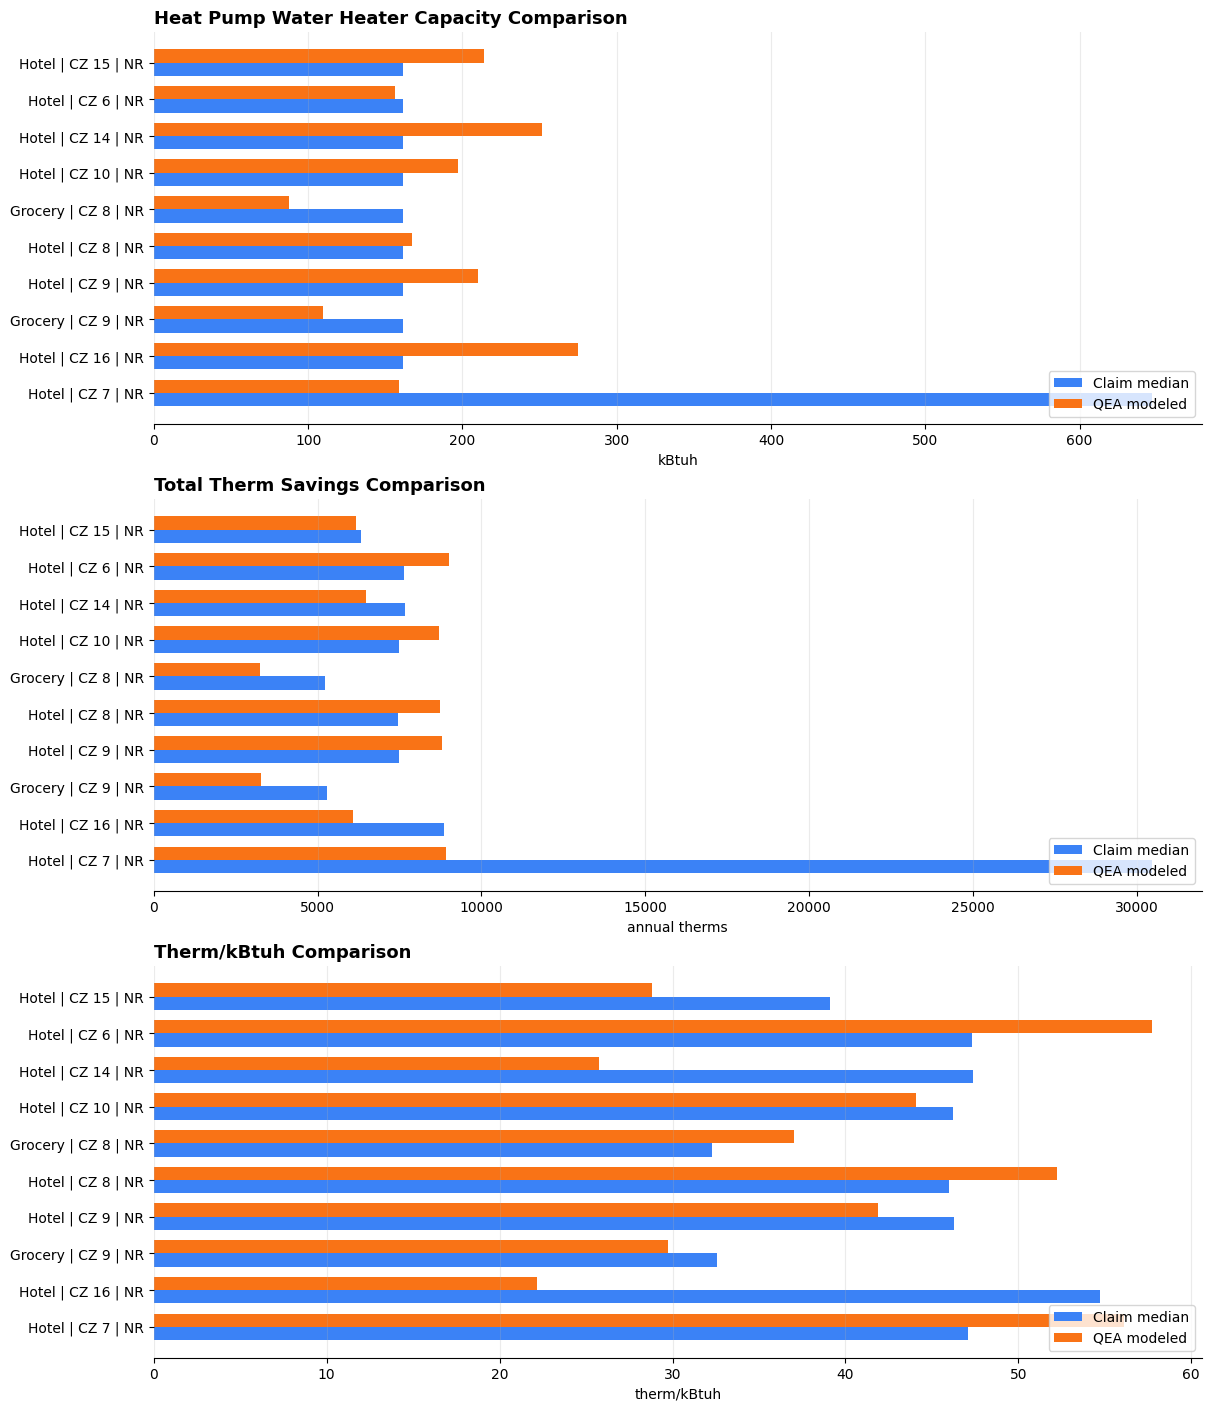

In [5]:
from pathlib import Path
import csv
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

CLAIMS_RAW_PATH = Path("..") / "claims_data_swwh028_222324.csv"
CLAIMED_NUNITS_DIR = Path("claimed nunits")
CLAIM_YEAR = 2024
CLAIMS_TOP10_OUTPUT_PATH = Path("claims_by_building_cz_measapp_tsb_top10.xlsx")
QEA_CAPACITY_PATH = Path("HPCapacity_QEA.xlsx")
MODEL_RUNS_DIR = Path("Model Runs ES")
OUTPUT_DIR = Path("outputs")

# Model Runs ES raw rows have an unquoted comma in Baseline ID, so read by raw position.
# Q = First baseline: Existing therms/kBtuh; R = Second baseline: Standard therms/kBtuh.
MODEL_EXISTING_THERM_PER_KBTUH_COL_INDEX = 16
MODEL_STANDARD_THERM_PER_KBTUH_COL_INDEX = 17

CLAIM_TO_MODEL_BUILDING = {
    "Hotel": "Htl",
    "Grocery": "Gro",
    "MFm": "MFm",
    "Nrs": "Nrs",
}
CLAIM_BUILDING_TYPE_MAP = {
    "GRO": "Grocery",
    "GROCERY": "Grocery",
    "HTL": "Hotel",
    "HOTEL": "Hotel",
    "MFM": "MFm",
    "NRS": "Nrs",
}


def normalize_cz(value):
    match = re.search(r"\d+", str(value))
    return str(int(match.group())) if match else str(value).strip()


def normalize_claim_building_type(value):
    text = str(value).strip()
    return CLAIM_BUILDING_TYPE_MAP.get(text.upper(), text)


def normalize_meas_app(value):
    text = str(value).strip().upper()
    if text in {"NR", "NORMAL REPLACEMENT"} or "NORMAL" in text:
        return "NR"
    if text in {"AR", "ACCELERATED REPLACEMENT"} or "ACCELERATED" in text:
        return "AR"
    if text == "NC":
        return "NC"
    return text


def baseline_column_for_meas_app(meas_app):
    meas_app = normalize_meas_app(meas_app)
    if meas_app == "AR":
        return "Existing", MODEL_EXISTING_THERM_PER_KBTUH_COL_INDEX
    # NR and NC compare to the standard/code baseline.
    return "Standard", MODEL_STANDARD_THERM_PER_KBTUH_COL_INDEX


def parse_number(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r"-?\d+(?:\.\d+)?", str(value).replace(",", ""))
    return float(match.group()) if match else np.nan


def normalize_column_name(value):
    return re.sub(r"[^a-z0-9]+", " ", str(value).lower()).strip()


def find_column(columns, required_terms):
    normalized = {column: normalize_column_name(column) for column in columns}
    for column, normalized_name in normalized.items():
        if all(term in normalized_name for term in required_terms):
            return column
    return None


def read_claimed_nunits_capacity(claimed_nunits_dir):
    rows = []
    for path in sorted(claimed_nunits_dir.glob("*")):
        if path.suffix.lower() == ".csv":
            data = pd.read_csv(path)
        elif path.suffix.lower() in {".xlsx", ".xlsm", ".xls"}:
            data = pd.read_excel(path, engine="openpyxl")
        else:
            continue

        columns = list(data.columns)
        hp_count_col = find_column(columns, ["number", "heat", "pump", "water", "heaters"])
        output_col = find_column(columns, ["output", "heating", "capacity", "heat", "pump"])
        capacity = data["NumUnits"].map(parse_number) if "NumUnits" in data else pd.Series(np.nan, index=data.index)
        if hp_count_col and output_col:
            calculated_capacity = data[hp_count_col].map(parse_number) * data[output_col].map(parse_number)
            capacity = capacity.fillna(calculated_capacity)

        rows.append(pd.DataFrame({
            "claim_year": pd.to_numeric(data.get("Year"), errors="coerce"),
            "claim_building_type": data.get("BldgType").map(normalize_claim_building_type),
            "claim_cz": data.get("BldgLoc").map(normalize_cz),
            "claim_measure_application_type": data.get("MeasAppType_DC").map(normalize_meas_app),
            "claim_data_request_capacity_kbtuh": capacity,
        }))

    if not rows:
        return pd.DataFrame(columns=[
            "claim_building_type",
            "claim_cz",
            "claim_measure_application_type",
            "claim_median_data_request_capacity_kbtuh",
        ])

    capacity_rows = pd.concat(rows, ignore_index=True)
    capacity_rows = capacity_rows[capacity_rows["claim_year"] == CLAIM_YEAR]
    return (
        capacity_rows.groupby(["claim_building_type", "claim_cz", "claim_measure_application_type"], as_index=False)
        .agg(claim_median_data_request_capacity_kbtuh=("claim_data_request_capacity_kbtuh", "median"))
    )


def build_claims_top10_for_year():
    raw_claims = pd.read_csv(CLAIMS_RAW_PATH)
    raw_claims = raw_claims[
        (pd.to_numeric(raw_claims["Year"], errors="coerce") == CLAIM_YEAR)
        & (raw_claims["Measure ID"].astype(str).str.upper() == "SWWH028")
    ].copy()
    raw_claims["claim_building_type"] = raw_claims["Building Type"].map(normalize_claim_building_type)
    raw_claims["claim_cz"] = raw_claims["Climate Zone"].map(normalize_cz)
    raw_claims["claim_measure_application_type"] = raw_claims["Measure Application Type"].map(normalize_meas_app)
    raw_claims["claim_pa_capacity_kbtuh"] = pd.to_numeric(raw_claims["Number of Units"], errors="coerce")
    raw_claims["claim_total_annual_therms_row"] = pd.to_numeric(raw_claims["First Year Gross Therm"], errors="coerce")
    raw_claims["claim_therm_per_kbtuh_row"] = raw_claims["claim_total_annual_therms_row"] / raw_claims["claim_pa_capacity_kbtuh"]

    grouped_claims = (
        raw_claims.groupby(["claim_building_type", "claim_cz", "claim_measure_application_type"], as_index=False)
        .agg(
            claim_rows=("Measure ID", "size"),
            claim_total_system_benefit=("Total System Benefit", "sum"),
            claim_median_pa_capacity_kbtuh=("claim_pa_capacity_kbtuh", "median"),
            claim_median_total_annual_therms=("claim_total_annual_therms_row", "median"),
            claim_median_therm_per_kbtuh=("claim_therm_per_kbtuh_row", "median"),
        )
    )
    grouped_claims["claim_tsb_share"] = grouped_claims["claim_total_system_benefit"] / grouped_claims["claim_total_system_benefit"].sum()
    grouped_claims = grouped_claims.sort_values("claim_tsb_share", ascending=False).head(10)

    data_request_capacity = read_claimed_nunits_capacity(CLAIMED_NUNITS_DIR)
    return grouped_claims.merge(
        data_request_capacity,
        on=["claim_building_type", "claim_cz", "claim_measure_application_type"],
        how="left",
    )


def read_qea_capacity(path):
    capacity = pd.read_excel(path, sheet_name="Sheet1", engine="openpyxl")
    capacity = capacity.rename(columns={"Building": "claim_building_type", "CZ": "claim_cz"})
    capacity["claim_cz"] = capacity["claim_cz"].map(normalize_cz)
    capacity["qea_modeled_capacity_raw"] = pd.to_numeric(capacity["HP Capacity"], errors="coerce")
    # HPCapacity_QEA stores Btu/h-like values. Convert to kBtuh for comparison.
    capacity["qea_modeled_capacity_kbtuh"] = capacity["qea_modeled_capacity_raw"] / 1000
    return capacity[["claim_building_type", "claim_cz", "qea_modeled_capacity_kbtuh"]]


def read_model_runs_for(meas_app):
    baseline_name, therm_col_index = baseline_column_for_meas_app(meas_app)
    rows = []
    for path in sorted(MODEL_RUNS_DIR.glob("*.csv")):
        by_key = {}
        with path.open(newline="", encoding="utf-8-sig") as file:
            reader = csv.reader(file)
            next(reader, None)
            for row in reader:
                if len(row) <= therm_col_index or not row or row[0] == "Sector":
                    continue
                try:
                    hour = int(float(row[11]))
                    therm_per_kbtuh = float(row[therm_col_index])
                except (TypeError, ValueError):
                    continue
                if hour < 1 or hour > 8760:
                    continue
                key = (row[1].strip(), normalize_cz(row[4]))
                by_key[key] = by_key.get(key, 0.0) + therm_per_kbtuh
        for (model_building_type, claim_cz), qea_therm_per_kbtuh in by_key.items():
            rows.append({
                "model_file": path.name,
                "model_building_type": model_building_type,
                "claim_cz": claim_cz,
                "claim_measure_application_type": normalize_meas_app(meas_app),
                "qea_model_baseline_source": baseline_name,
                "qea_modeled_therm_per_kbtuh": qea_therm_per_kbtuh,
            })
    return pd.DataFrame(rows)


claims = build_claims_top10_for_year()
claims["claim_cz"] = claims["claim_cz"].map(normalize_cz)
claims["claim_measure_application_type"] = claims["claim_measure_application_type"].map(normalize_meas_app)
claims["model_building_type"] = claims["claim_building_type"].map(CLAIM_TO_MODEL_BUILDING)
claims_top10_output = claims.drop(columns=["model_building_type"], errors="ignore").copy()
claims_top10_output.insert(0, "claim_year", CLAIM_YEAR)

OUTPUT_DIR.mkdir(exist_ok=True)
claims_top10_csv_output = OUTPUT_DIR / f"claims_by_building_cz_measapp_tsb_top10_{CLAIM_YEAR}.csv"
claims_top10_xlsx_output = OUTPUT_DIR / f"claims_by_building_cz_measapp_tsb_top10_{CLAIM_YEAR}.xlsx"
claims_top10_output.to_csv(claims_top10_csv_output, index=False, float_format="%.6f")
for path in [CLAIMS_TOP10_OUTPUT_PATH, claims_top10_xlsx_output]:
    try:
        claims_top10_output.to_excel(path, index=False)
        print(f"Wrote {path}")
    except PermissionError:
        print(f"Could not write {path}; close it in Excel and rerun this cell.")
print(f"Wrote {claims_top10_csv_output}")

qea_capacity = read_qea_capacity(QEA_CAPACITY_PATH)
model_runs = pd.concat(
    [read_model_runs_for(meas_app) for meas_app in sorted(claims["claim_measure_application_type"].dropna().unique())],
    ignore_index=True,
)

model_summary = (
    model_runs.groupby(["model_building_type", "claim_cz", "claim_measure_application_type", "qea_model_baseline_source"], as_index=False)
    .agg(
        qea_modeled_therm_per_kbtuh=("qea_modeled_therm_per_kbtuh", "median"),
        qea_modeled_therm_per_kbtuh_min=("qea_modeled_therm_per_kbtuh", "min"),
        qea_modeled_therm_per_kbtuh_max=("qea_modeled_therm_per_kbtuh", "max"),
        qea_model_run_count=("model_file", "nunique"),
        qea_model_files=("model_file", lambda values: ", ".join(sorted(set(map(str, values))))),
    )
)

comparison = (
    claims.merge(qea_capacity, on=["claim_building_type", "claim_cz"], how="left")
    .merge(model_summary, on=["model_building_type", "claim_cz", "claim_measure_application_type"], how="left")
)
comparison["qea_modeled_annual_total_therms"] = (
    comparison["qea_modeled_therm_per_kbtuh"] * comparison["qea_modeled_capacity_kbtuh"]
)
comparison["qea_modeled_capacity_minus_claim_median_data_request_kbtuh"] = (
    comparison["qea_modeled_capacity_kbtuh"] - comparison["claim_median_data_request_capacity_kbtuh"]
)
comparison["qea_modeled_capacity_pct_diff_vs_claim_median_data_request"] = (
    comparison["qea_modeled_capacity_minus_claim_median_data_request_kbtuh"]
    / comparison["claim_median_data_request_capacity_kbtuh"]
)
comparison["qea_modeled_annual_therms_minus_claim_median"] = (
    comparison["qea_modeled_annual_total_therms"] - comparison["claim_median_total_annual_therms"]
)
comparison["qea_modeled_annual_therms_pct_diff_vs_claim_median"] = (
    comparison["qea_modeled_annual_therms_minus_claim_median"]
    / comparison["claim_median_total_annual_therms"]
)
comparison["qea_modeled_therm_per_kbtuh_minus_claim_median"] = (
    comparison["qea_modeled_therm_per_kbtuh"] - comparison["claim_median_therm_per_kbtuh"]
)
comparison["qea_modeled_therm_per_kbtuh_pct_diff_vs_claim_median"] = (
    comparison["qea_modeled_therm_per_kbtuh_minus_claim_median"]
    / comparison["claim_median_therm_per_kbtuh"]
)

display_columns = [
    "claim_building_type",
    "claim_cz",
    "claim_measure_application_type",
    "claim_rows",
    "claim_tsb_share",
    "claim_median_data_request_capacity_kbtuh",
    "qea_modeled_capacity_kbtuh",
    "qea_modeled_capacity_pct_diff_vs_claim_median_data_request",
    "claim_median_total_annual_therms",
    "qea_modeled_annual_total_therms",
    "qea_modeled_annual_therms_pct_diff_vs_claim_median",
    "claim_median_therm_per_kbtuh",
    "qea_modeled_therm_per_kbtuh",
    "qea_modeled_therm_per_kbtuh_pct_diff_vs_claim_median",
    "qea_model_baseline_source",
    "qea_model_run_count",
]

pct_diff_columns = [column for column in comparison.columns if "pct_diff" in column]
pct_diff_display_names = {column: f"{column} (%)" for column in pct_diff_columns}
comparison_output = comparison.rename(columns=pct_diff_display_names).copy()
for source_column, output_column in pct_diff_display_names.items():
    comparison_output[output_column] = comparison[source_column] * 100

display_columns_output = [pct_diff_display_names.get(column, column) for column in display_columns]
display_format = {
    column: "{:,.1f}%"
    for column in display_columns_output
    if column.endswith("(%)")
}
for column in display_columns_output:
    if column not in display_format and pd.api.types.is_numeric_dtype(comparison_output[column]):
        display_format[column] = "{:,.3f}"

OUTPUT_DIR.mkdir(exist_ok=True)
csv_output = OUTPUT_DIR / "claims_top10_qea_model_comparison.csv"
xlsx_output = OUTPUT_DIR / "claims_top10_qea_model_comparison.xlsx"
comparison_output.to_csv(csv_output, index=False, float_format="%.6f")
comparison_output.to_excel(xlsx_output, index=False)

print(f"Wrote {csv_output}")
print(f"Wrote {xlsx_output}")
display(comparison_output[display_columns_output].style.format(display_format))

visual_data = comparison_output[display_columns_output].copy()
visual_data["building_type"] = visual_data["claim_building_type"].astype(str)
visual_data["category"] = (
    "CZ "
    + visual_data["claim_cz"].astype(str)
    + " | "
    + visual_data["claim_measure_application_type"].astype(str)
)
visual_data = visual_data.sort_values(["building_type", "claim_cz", "claim_measure_application_type"]).reset_index(drop=True)

chart_specs = [
    (
        "Heat Pump Water Heater Capacity Comparison",
        "claim_median_data_request_capacity_kbtuh",
        "qea_modeled_capacity_kbtuh",
        "kBtuh",
    ),
    (
        "Total Therm Savings Comparison",
        "claim_median_total_annual_therms",
        "qea_modeled_annual_total_therms",
        "annual therms",
    ),
    (
        "Therm/kBtuh Comparison",
        "claim_median_therm_per_kbtuh",
        "qea_modeled_therm_per_kbtuh",
        "therm/kBtuh",
    ),
]

bar_height = 0.36
claim_color = "#3b82f6"
qea_color = "#f97316"


def plot_building_type_comparison(building_data, axes, building_type, show_y_labels=True):
    building_data = building_data.iloc[::-1].reset_index(drop=True)
    y_positions = np.arange(len(building_data))
    for ax, (title, claim_column, qea_column, x_label) in zip(axes, chart_specs):
        ax.barh(
            y_positions - bar_height / 2,
            building_data[claim_column],
            height=bar_height,
            label="Claim median",
            color=claim_color,
        )
        ax.barh(
            y_positions + bar_height / 2,
            building_data[qea_column],
            height=bar_height,
            label="QEA modeled",
            color=qea_color,
        )
        ax.set_title(f"{building_type}: {title}", loc="left", fontsize=13, fontweight="bold")
        ax.set_xlabel(x_label)
        ax.set_yticks(y_positions)
        ax.set_yticklabels(building_data["category"] if show_y_labels else [])
        ax.grid(axis="x", alpha=0.25)
        ax.spines[["top", "right", "left"]].set_visible(False)
        ax.legend(loc="lower right")


building_types = list(visual_data["building_type"].dropna().drop_duplicates())
fig, axes = plt.subplots(
    nrows=len(building_types) * len(chart_specs),
    ncols=1,
    figsize=(12, max(5, 4.2 * len(building_types) * len(chart_specs))),
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

for building_index, building_type in enumerate(building_types):
    start = building_index * len(chart_specs)
    building_data = visual_data[visual_data["building_type"].eq(building_type)].copy()
    plot_building_type_comparison(
        building_data,
        axes[start:start + len(chart_specs)],
        building_type,
    )

visual_output = OUTPUT_DIR / "qea_claims_top10_visual_comparison.png"
fig.savefig(visual_output, dpi=200, bbox_inches="tight")
print(f"Wrote {visual_output}")
display(fig)
plt.close(fig)

for building_type in building_types:
    building_data = visual_data[visual_data["building_type"].eq(building_type)].copy()
    fig, axes = plt.subplots(nrows=len(chart_specs), ncols=1, figsize=(12, 12), constrained_layout=True)
    plot_building_type_comparison(building_data, np.atleast_1d(axes), building_type)
    building_slug = re.sub(r"[^A-Za-z0-9]+", "_", building_type).strip("_").lower()
    building_visual_output = OUTPUT_DIR / f"qea_claims_top10_visual_comparison_{building_slug}.png"
    fig.savefig(building_visual_output, dpi=200, bbox_inches="tight")
    print(f"Wrote {building_visual_output}")
    plt.close(fig)
